In [294]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
from importlib import reload

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/camp/home/tootoos/working/tootoos/conda-envs/numpyro-env/lib/python3.10/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['inspect']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [295]:
import glom_io_transform as glom; reload(glom)
from glom_io_transform import paths; reload(paths)
from glom_io_transform.model_fitting import common; reload(common)


proj_path='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform'
fits_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting'
data_root='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/data'


<module 'glom_io_transform.model_fitting.common' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/common.py'>

In [296]:
data_root = paths.data_root
assert os.path.exists(data_root), f"Path {data_root} does not exist"
with open(os.path.join(data_root, "X0Y0_new.p"), "rb") as f:
    data = pickle.load(f)
    X0 = data["X0"]
    Y0 = data["Y0"]


In [297]:
Xtrain, Xtest, Xvld, *_ = common.split(X0)
Ytrain, Ytest, Yvld, *_ = common.split(Y0)

In [298]:
from glom_io_transform.model_fitting import proc_fit_models as pfm
reload(pfm)
# model_train = copy(models)
from glom_io_transform.model_fitting import driver
reload(driver)
from glom_io_transform.model_fitting.driver import RunResults

### Load the fitted models

In [299]:
loaded_models = {}

In [300]:
proj_path = paths.proj_path
print(proj_path)

/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform


In [317]:
from glom_io_transform.model_fitting import layout
from importlib import reload
import glom_io_transform.model_fitting.proc_fit_models as pfm
reload(pfm)
standardization = "separate"
normalization   = "odour_std"
center          = True
sampler         = "trials"
mode            = "random"
matched         = True
loss        = "resp"
n_od_train      = "18_rand_0"
base_dir = layout.build_fit_dir(name="FOOBAR",
    root = os.path.join(proj_path, "model_fitting/fits"),
                                center = center,
                                standardization = standardization,
                                normalization   = normalization,
                                sampler_type    = sampler,
                                split_mode      = mode,
                                n_od_train      = n_od_train,
                                matched         = matched,
                                loss            = loss
                                )
base_dir = base_dir.replace("/FOOBAR", "")
assert os.path.exists(base_dir), f"Base directory {base_dir} does not exist"
print(f"{base_dir=}")

base_dir='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/loss=resp/matched=True/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=18_rand_0'


In [318]:
loaded_models_path = os.path.join(base_dir, "loaded_models.p")
assert os.path.exists(loaded_models_path), f"Loaded models file {loaded_models_path} does not exist. Run driver.py --loadmodels first."
with open(loaded_models_path, "rb") as f:
    loaded_models[base_dir] = pickle.load(f)
models = loaded_models[base_dir]

In [319]:
print(base_dir)
out_file = os.path.join(base_dir, "ffree", "out.0.p")
assert os.path.exists(out_file), f"Output file {out_file} does not exist"
from glom_io_transform.model_fitting.results import load_pickle
out = load_pickle(out_file)

/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/glom_io_transform/model_fitting/fits/loss=resp/matched=True/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=18_rand_0


In [320]:
out["results"]["mdl.results"]

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.007526318152114515
        x: [-3.518e-01  1.112e+00 ...  3.440e-01 -4.295e-01]
      nit: 62
      jac: [ 6.387e-09  1.209e-08 ... -1.088e-07  1.342e-08]
     nfev: 64
     njev: 64
 hess_inv: <256x256 LbfgsInvHessProduct with dtype=float64>

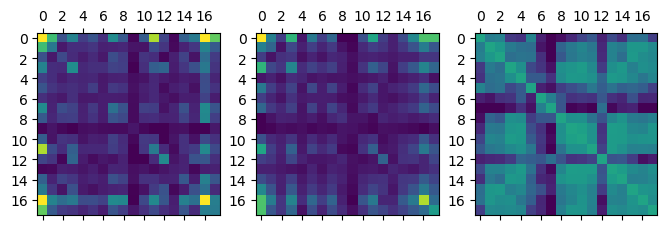

In [321]:
r = out["results"]["split"].trains[0]
from glom_io_transform.model_fitting.conn_models.common import compute_ratio
compute_ratio(r.Cstar, r.Cest, r.Cin)
fig, ax = plt.subplots(1, 3, figsize=(8, 3))
vlim = np.percentile(r.Cstar, [1, 99])
[axi.matshow(C, vmin=vlim[0], vmax=vlim[1]) for axi, C in zip(ax, [r.Cstar, r.Cest, r.Cin])
]

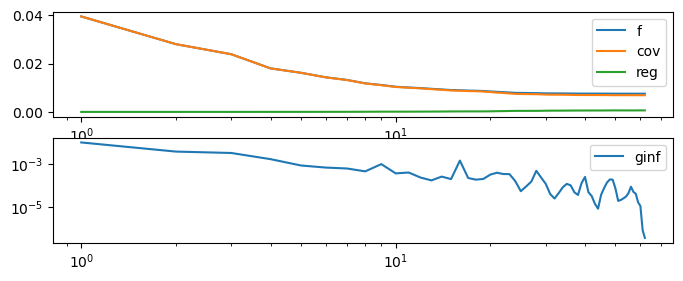

In [322]:
out["results"]["history"].keys()
def plot_history(history):
    it = history["it"]
    f  = history["f"]
    cov = history["cov"]
    reg = history["reg"]
    ginf = history["ginf"]
    subplot(2,1,1)
    semilogx(it, f, label="f")
    plot(it, cov, label="cov")
    plot(it, reg, label="reg")
    legend()
    subplot(2,1,2)
    loglog(it, ginf, label="ginf")
    legend()
plot_history(out["results"]["history"])

In [323]:
df = models["Free"]["df"]
df[(df.λ == 1e-3) & (df.seed == 0)]

,seed,split,ref,is_cross,file,sampler_type,mode,outclass,train_odours,test_odours,...,n_od_train,r2,pearson,spearman,ratio,r2_resp,pearson_resp,spearman_resp,ratio_resp,λ
21210,0,trains,train[0],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.729237,0.906606,0.798793,0.172556,0.822026,0.909984,0.873599,0.070656,0.001
21211,0,trains,train[1],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.511037,0.758468,0.727878,0.164001,0.703994,0.849015,0.862609,0.101987,0.001
21212,0,trains,train[2],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.680211,0.891914,0.730722,0.216353,0.814006,0.908427,0.867958,0.077036,0.001
21213,0,trains,train[3],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.687753,0.852859,0.740348,0.187674,0.793719,0.891898,0.878006,0.077691,0.001
21214,0,trains,train[4],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.732818,0.909402,0.794336,0.171225,0.832443,0.916774,0.880803,0.067505,0.001
21215,0,trains,train[5],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.707721,0.888942,0.710548,0.184252,0.805140,0.899255,0.858605,0.076899,0.001
21216,0,trains,train[6],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.698151,0.850615,0.721225,0.166783,0.701926,0.838886,0.843020,0.113790,0.001
21217,0,trains,train[7],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.699456,0.898231,0.710956,0.205025,0.804601,0.903736,0.845354,0.081955,0.001
21218,0,trains,train[8],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.610957,0.841853,0.708148,0.267012,0.787643,0.889532,0.868370,0.084136,0.001
21219,0,trains,train[9],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),...,18,0.056183,0.736043,0.674822,0.171350,0.640147,0.834852,0.855747,0.116345,0.001


# # Process fitted models

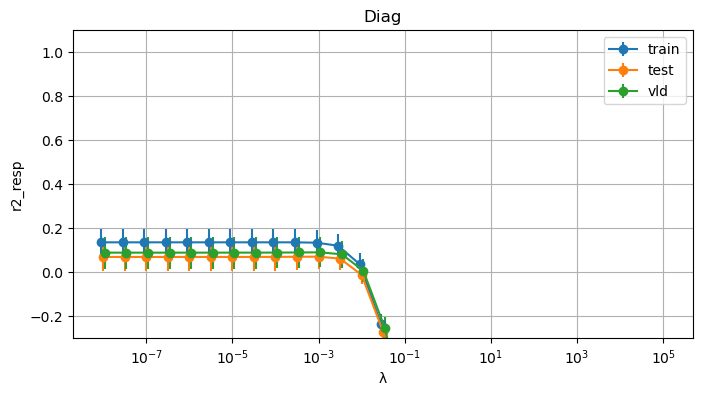

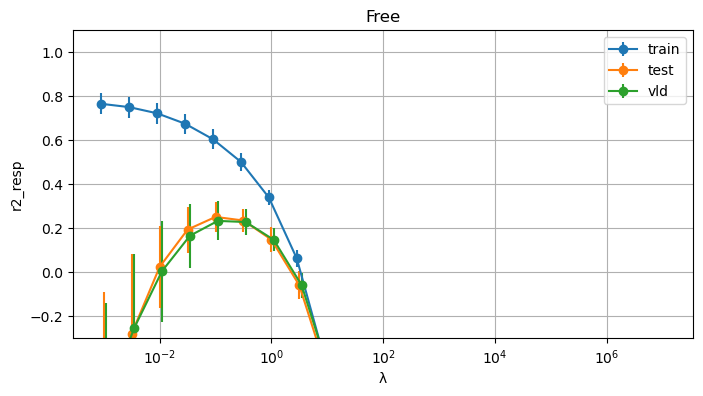

In [331]:
# For each model, count the number of parameters it has.
# If it has one parameter, plot the mean and std of the the ratio parameter for the train, test and vld sets.
subset_params = {}
stat = 'r2_resp' if loss == "resp" else 'r2'
identity = lambda x: x
yl = (-0.3,1.1)
for name, mdl in sorted(models.items()):
#    if name not in ["Diag", "Free"]: #["Free", "FreeSym", "FreeAsym"]: #["Diag", "Diag101"]:
    #        continue
    # Copy mdl

    mdl = deepcopy(mdl)
    
    df = mdl["df"]
    descr = name 
    if name in subset_params:
        for k, v in subset_params[name].items():
            df = df[df[k] == v]
            # Remove k from the parameters
            print(f"Set {k}={v}. Removing from params list.")
            mdl["params"].remove(k)
            descr += f" {k}={v}"
            
    if len(mdl["params"]) == 2:
        p0, p1  = mdl["params"]
        p0_vals = np.unique(df[p0].values)
        p1_vals = np.unique(df[p1].values)
        vals    = np.zeros((3, len(p0_vals), len(p1_vals)))
        figure(figsize=(12,4))        
        # Fill a matrix called ratio_test with the mean of the ratio_test values using the sort order of the λ0 and λ1 values as indices
        for ifld, fld  in enumerate(['train', 'test','vld']):
            for i, v0 in enumerate(p0_vals):
                for j, v1 in enumerate(p1_vals):
                    # Group the rows of df by the two parameters and take the mean of the ratio_test column                    
                    vals[ifld, i, j] = df[(df[p0] == v0) & (df[p1] == v1)][f'{stat}_{fld}'].mean()
            
            subplot(1,3,ifld+1)
            # Plot the ratio_test values as a function of λ1 and λ2
            #vmin = max(0.5, vals[ifld].min())
            #vmax = min(1.5, vals[ifld].max())
            vmin, vmax = percentile(vals[ifld], [1, 99])
            vmin, vmax = max(vmin,0), min(vmax, 2)
            vmin, vmax = sorted([vmin, vmax])
            matshow(vals[ifld], cmap='Spectral_r', vmin = vmin, vmax = vmax, fignum=False); axis("auto"); colorbar()
            # Use the log10 of the λ values for the x and y ticks
            # Label using the :g format option to avoid scientific notation
            tform = lambda p: (identity if p[0] != 'λ' else log10)
            tname = lambda p: ("" if p[0] != 'λ' else "log10")
            yticks(range(len(p0_vals)), [f'{tform(p0)(p):g}' for p in p0_vals]); ylabel(f"{tname(p0)} {p0}")
            xticks(range(len(p1_vals)), [f'{tform(p1)(p):g}' for p in p1_vals]); xlabel(f"{tname(p1)} {p1}")
            title(f'{stat}_{fld} as a function of {p0} and {p1}', pad=1)
            tight_layout()
        suptitle(descr, y = 1.0)

    if len(mdl["params"]) == 1:
        param = mdl["params"][0]
        figure(figsize=(8, 4))
        for i, fld in enumerate(['train', 'test', 'vld']):
            mask = df["split"].str.startswith("train") if fld == "train" else df["split"] == fld
            sub = df[mask]
            stat_mean = sub.groupby(param)[stat].mean()
            stat_std  = sub.groupby(param)[stat].std()
            if mdl["params"][0] == "λ":
                # Use a log scale for the x-axis
                plt.xscale('log')
            # Stagger the x-values for the train, test, and validation sets
            errorbar(stat_mean.index * (0.9+i/10), stat_mean, yerr=stat_std, label=fld, marker='o')
        xlabel(param)
        ylabel(f'{stat}')
        if yl is None:
            yl = list(ylim()) 
            yl[0] = max(yl[0], 0)
            yl[1] = min(yl[1], 2)       
        ylim(yl)
        legend()
        title(descr)
        grid(True)
#xlim(9,1100)